In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# COMPARANDO CATEGORIAS

Os gráficos deste capítulo visam ajudar nossos leitores a comparar valores entre categorias. Barras, linhas e pontos permitem que os leitores façam comparações tanto dentro de grupos quanto entre eles. Em alguns casos, queremos que o leitor visualize tanto os níveis quanto as variações, ou alguma outra combinação de variáveis; em outros, queremos concentrar sua atenção em uma comparação específica.

O desafio ao comparar dados categóricos é decidir o que queremos que o gráfico transmita. Existe um argumento ou uma narrativa principal? Há algum aspecto que possa ser identificado como a comparação mais importante que se deseja que o leitor faça? Como criadores de gráficos, precisamos priorizar a função que queremos que eles desempenhem. Ao incluir todas as barras ou pontos no gráfico, podemos acabar obscurecendo a mensagem que desejamos transmitir.

Este capítulo começa com o gráfico de barras. Assim como o gráfico de linhas que dará início ao próximo capítulo, o gráfico de barras é familiar à maioria dos leitores, o que o torna uma escolha conveniente para orientá-los ao comparar categorias ou observar mudanças ao longo do tempo. Ele também ocupa o topo do diagrama de hierarquia de percepção visual. Não é obrigatório fornecer sempre os valores exatos aos leitores, mas, quando o fazemos, o gráfico de barras é uma excelente escolha.



## GRÁFICOS MARIMEKKO E DE MOSAICO

Os gráficos Marimekko podem parecer estranhos à primeira vista, mas são apenas uma extensão do gráfico de barras. Esse tipo de gráfico é útil quando se deseja fazer comparações entre duas variáveis: uma que compara categorias e outra que mostra como elas se somam para formar um total. O nome do gráfico deriva da empresa de design finlandesa Marimekko, fundada em 1951 por Armi Ratia e seu marido, Viljo. O estilo inicial da Marimekko caracterizava-se por padrões geométricos retos e de grandes dimensões, além de cores vibrantes.

No gráfico de barras verticais (ou colunas) padrão, os dados são medidos ao longo da altura do eixo vertical e as larguras das colunas são idênticas. O gráfico Marimekko utiliza esse gráfico de colunas padrão e expande a largura de cada barra de acordo com outro valor de dados. O gráfico Marimekko é uma maneira fácil de adicionar uma segunda variável ao seu gráfico de colunas ou barras padrão.

Neste gráfico Marimekko, apresento duas variáveis ​​referentes aos dez países mais populosos: a proporção de pessoas com renda inferior a US$ 4,20 por dia e a participação de cada país no total da população desse grupo. O percentual de pessoas com renda inferior a US$ 4,20 por dia é representado no eixo vertical, como em um gráfico de barras convencional; já a largura de cada barra é definida com base na participação da população de cada país, de modo que a soma das larguras totalize 100% entre esses dez países (uma alternativa seria exibir os números absolutos em vez de percentuais). É possível visualizar quais são os países mais populosos desta amostra — representados pelas barras mais largas — e como a pobreza se distribui entre eles. Também é possível utilizar as cores de forma estratégica: se este gráfico ilustrasse um artigo sobre a pobreza no Brasil e na China, por exemplo, poderíamos aplicar a mesma cor a todas as barras, exceto às desses dois países, como se vê no gráfico à direita.

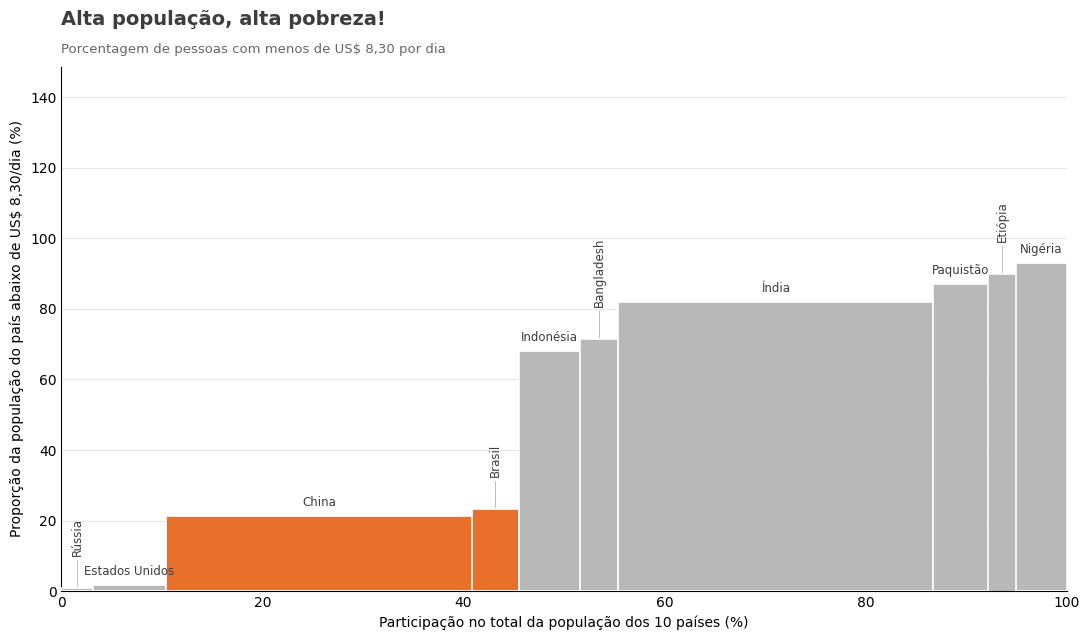

In [2]:
marimekko = pd.read_csv("../Data/marimekko_pobreza_top10_usd830.csv", sep="\t", encoding="utf-16")
marimekko = marimekko.rename(columns={
    "país": "País",
    "população total": "População_total",
    "proporção de pessoas com renda inferior a US$ 8,30 por dia": "Proporção",
})
marimekko = marimekko.sort_values("Proporção", ascending=True).reset_index(drop=True)

GRAFITE = "#3D3D3D"
LARANJA = "#E8702A"
CINZA = "#B8B8B8"
DESTAQUE = {"Brasil", "China"}  # países em evidência: mesma cor para os demais

# largura da barra = participação de cada país no total da população dos 10 países
larguras = marimekko["População_total"].to_numpy() / marimekko["População_total"].sum() * 100
alturas = marimekko["Proporção"].to_numpy() * 100
bordas = np.concatenate([[0], np.cumsum(larguras)])
centros = bordas[:-1] + larguras / 2
cores = [LARANJA if pais in DESTAQUE else CINZA for pais in marimekko["País"]]

fig, ax = plt.subplots(figsize=(11, 6.5))

for esquerda, largura, altura, pais, cor in zip(bordas[:-1], larguras, alturas, marimekko["País"], cores):
    # segmentos estreitos ganham borda mais fina para a cor não ser "engolida"
    contorno = 0.4 if largura < 3 else 1.2
    ax.bar(esquerda, altura, width=largura, align="edge", color=cor,
           edgecolor="white", linewidth=contorno, zorder=3)
    centro = esquerda + largura / 2

# Rótulos dos países: segmentos estreitos recebem texto vertical e altura
# escalonada (com linha guia) para evitar sobreposição entre vizinhos
sequencia_estreita = 0
for centro, largura, altura, pais in zip(centros, larguras, alturas, marimekko["País"]):
    if largura >= 5:
        topo_rotulo = altura + 2
        sequencia_estreita = 0
    else:
        topo_rotulo = altura + 9 + sequencia_estreita * 13
        sequencia_estreita += 1
        ax.plot([centro, centro], [altura + 0.5, topo_rotulo - 1], color="#BDBDBD",
                linewidth=0.7, zorder=2)
    ax.text(centro, topo_rotulo, pais, ha="center", va="bottom",
            fontsize=8.5, color=GRAFITE, rotation=90 if largura < 5 else 0)

ax.set_xlim(0, 100)
ax.set_ylim(0, alturas.max() * 1.6)
ax.set_xlabel("Participação no total da população dos 10 países (%)")
ax.set_ylabel("Proporção da população do país abaixo de US$ 8,30/dia (%)")

# Título em estilo manchete + subtítulo
ax.set_title("Alta população, alta pobreza!", loc="left", fontsize=14,
             color=GRAFITE, weight="bold", pad=30)
ax.text(0, 1.02, "Porcentagem de pessoas com menos de US$ 8,30 por dia",
        transform=ax.transAxes, fontsize=9.5, color="#666666", va="bottom")

ax.yaxis.grid(True, color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
ax.tick_params(length=0)

fig.tight_layout()
plt.show()

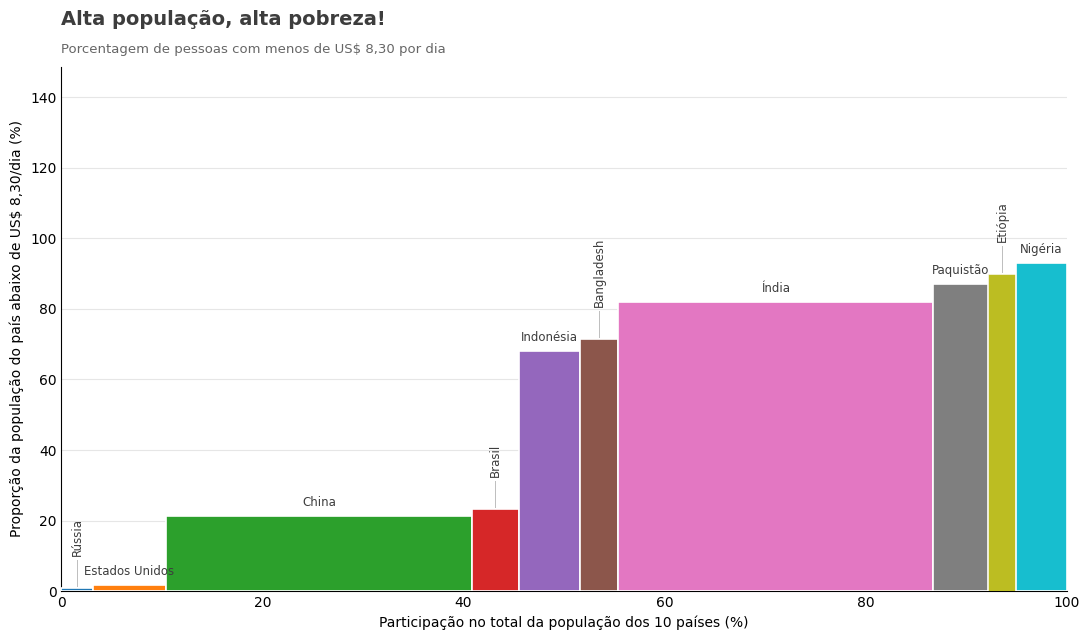

In [3]:
# Mesmo gráfico, mas com uma cor distinta para cada país (sem destaque único)
paleta_paises = plt.cm.tab10.colors + plt.cm.tab20.colors
cores_paises = dict(zip(marimekko["País"], paleta_paises))

fig, ax = plt.subplots(figsize=(11, 6.5))

for esquerda, largura, altura, pais in zip(bordas[:-1], larguras, alturas, marimekko["País"]):
    contorno = 0.4 if largura < 3 else 1.2
    ax.bar(esquerda, altura, width=largura, align="edge", color=cores_paises[pais],
           edgecolor="white", linewidth=contorno, zorder=3)

sequencia_estreita = 0
for centro, largura, altura, pais in zip(centros, larguras, alturas, marimekko["País"]):
    if largura >= 5:
        topo_rotulo = altura + 2
        sequencia_estreita = 0
    else:
        topo_rotulo = altura + 9 + sequencia_estreita * 13
        sequencia_estreita += 1
        ax.plot([centro, centro], [altura + 0.5, topo_rotulo - 1], color="#BDBDBD",
                linewidth=0.7, zorder=2)
    ax.text(centro, topo_rotulo, pais, ha="center", va="bottom",
            fontsize=8.5, color=GRAFITE, rotation=90 if largura < 5 else 0)

ax.set_xlim(0, 100)
ax.set_ylim(0, alturas.max() * 1.6)
ax.set_xlabel("Participação no total da população dos 10 países (%)")
ax.set_ylabel("Proporção da população do país abaixo de US$ 8,30/dia (%)")

ax.set_title("Alta população, alta pobreza!", loc="left", fontsize=14,
             color=GRAFITE, weight="bold", pad=30)
ax.text(0, 1.02, "Porcentagem de pessoas com menos de US$ 8,30 por dia",
        transform=ax.transAxes, fontsize=9.5, color="#666666", va="bottom")

ax.yaxis.grid(True, color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
ax.tick_params(length=0)

fig.tight_layout()
plt.show()

As duas variáveis ​​também poderiam ser representadas separadamente em dois gráficos de barras; embora esses gráficos sejam familiares e fáceis de ler, eles não transmitem tão bem a relação entre as duas variáveis.

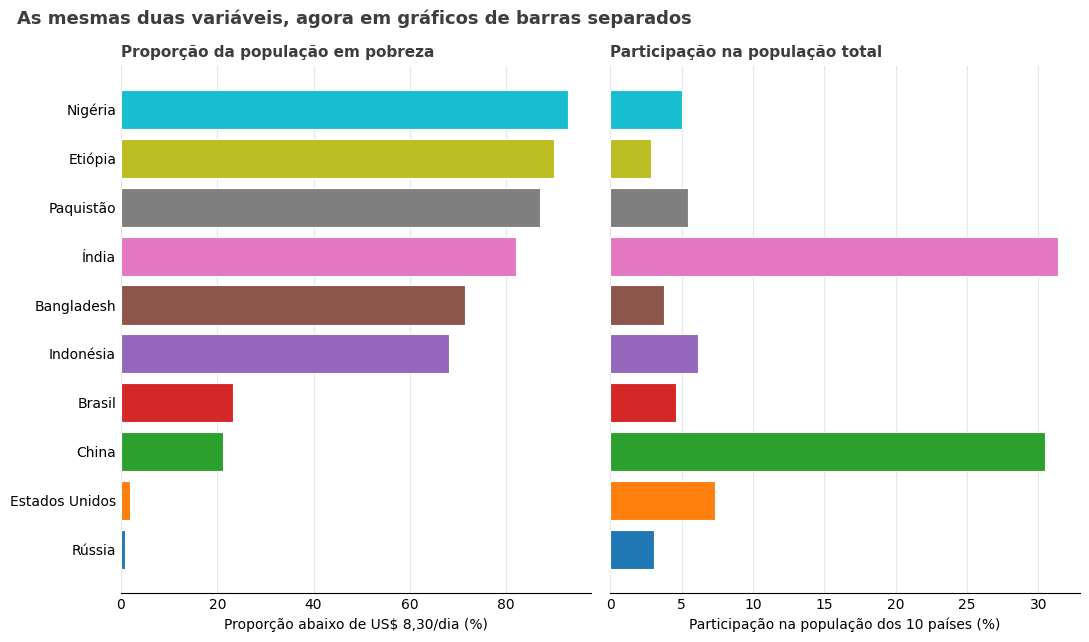

In [4]:
# As mesmas duas variáveis em gráficos de barras separados (barras horizontais)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 6.5), sharey=True)

pos = np.arange(len(marimekko))
cores_barras = [cores_paises[pais] for pais in marimekko["País"]]

ax1.barh(pos, alturas, color=cores_barras, edgecolor="white", linewidth=0.8, zorder=3)
ax1.set_yticks(pos, marimekko["País"])
ax1.set_xlabel("Proporção abaixo de US$ 8,30/dia (%)")
ax1.set_title("Proporção da população em pobreza", loc="left", fontsize=11,
              color=GRAFITE, weight="bold")

ax2.barh(pos, larguras, color=cores_barras, edgecolor="white", linewidth=0.8, zorder=3)
ax2.set_xlabel("Participação na população dos 10 países (%)")
ax2.set_title("Participação na população total", loc="left", fontsize=11,
              color=GRAFITE, weight="bold")

for ax in (ax1, ax2):
    ax.xaxis.grid(True, color="#E6E6E6", linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.tick_params(length=0)

fig.suptitle("As mesmas duas variáveis, agora em gráficos de barras separados",
             x=0.02, ha="left", fontsize=13, color=GRAFITE, weight="bold")
fig.tight_layout()
plt.show()

Ao colocar duas variáveis ​​em um gráfico, você pode acabar refletindo sobre a associação ou a relação entre elas. Se for esse o caso, é possível visualizar essa relação utilizando outros tipos de gráfico. Tracei os mesmos dados neste gráfico de dispersão (veja também a página 249). É possível notar que a China e a Índia se destacam como *outliers* (valores atípicos), especialmente no eixo da população; no entanto, o gráfico não transmite a proporção de cada uma em relação ao todo populacional. O gráfico de coordenadas paralelas à direita (veja também a página 263) mostra, de forma semelhante, a magnitude populacional muito maior da China e da Índia, bem como o fato de que uma parcela maior da população indiana vive com US$ 5,20 por dia. (Um possível problema com o gráfico de coordenadas paralelas é que as linhas podem sugerir, para alguns leitores, uma mudança ao longo do tempo, quando, na verdade, o gráfico está sendo usado aqui apenas para comparar as duas variáveis.)

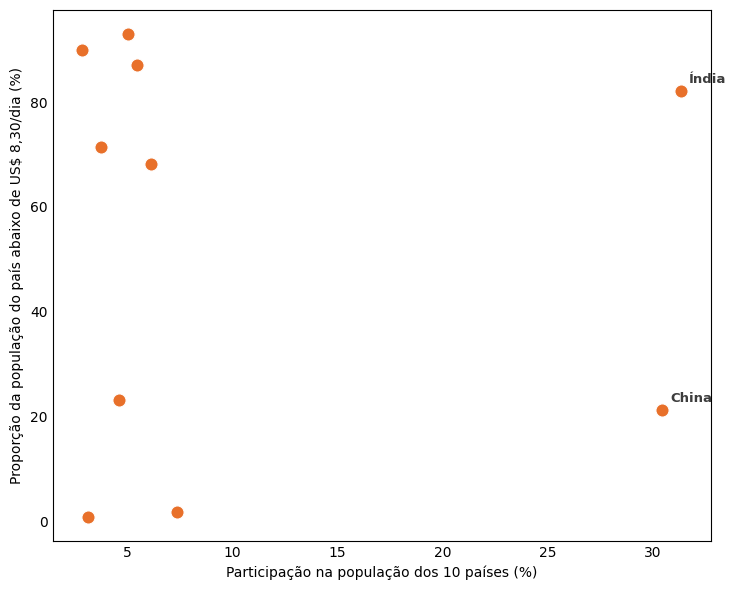

In [5]:
# As mesmas duas variáveis em um gráfico de dispersão, com a mesma cor para todos os países
fig, ax = plt.subplots(figsize=(7.5, 6))

ax.scatter(larguras, alturas, color=LARANJA, edgecolor="white", linewidth=0.8, s=90, zorder=3)

for pais, largura, altura in zip(marimekko["País"], larguras, alturas):
    if pais in ("China", "Índia"):
        ax.annotate(pais, (largura, altura), xytext=(6, 6), textcoords="offset points",
                    fontsize=9.5, color=GRAFITE, fontweight="bold")

ax.set_xlabel("Participação na população dos 10 países (%)")
ax.set_ylabel("Proporção da população do país abaixo de US$ 8,30/dia (%)")
ax.tick_params(length=0)

fig.tight_layout()
plt.show()

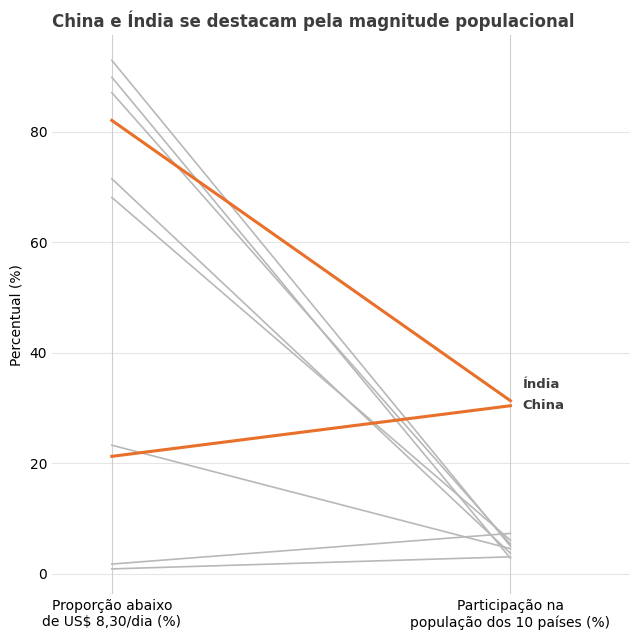

In [6]:
# As mesmas duas variáveis em um gráfico de coordenadas paralelas
fig, ax = plt.subplots(figsize=(6.5, 6.5))

eixos = [0, 1]
destaques_ordenados = sorted(
    [(pais, altura, largura) for pais, altura, largura in zip(marimekko["País"], alturas, larguras)
     if pais in ("China", "Índia")],
    key=lambda item: item[2])

for pais, altura, largura in zip(marimekko["País"], alturas, larguras):
    destaque = pais in ("China", "Índia")
    cor = LARANJA if destaque else CINZA
    ax.plot(eixos, [altura, largura], color=cor, linewidth=2.2 if destaque else 1.2,
            zorder=3 if destaque else 2)

# Rótulos escalonados para não sobrepor (Índia e China terminam com valores próximos)
for i, (pais, altura, largura) in enumerate(destaques_ordenados):
    ax.text(1.03, largura + i * 3, pais, ha="left", va="center", fontsize=9.5,
            color=GRAFITE, fontweight="bold")

ax.set_xlim(-0.15, 1.3)
ax.set_xticks(eixos, ["Proporção abaixo\nde US$ 8,30/dia (%)", "Participação na\npopulação dos 10 países (%)"])
ax.set_ylabel("Percentual (%)")
ax.set_title("China e Índia se destacam pela magnitude populacional",
             loc="left", fontsize=12, color=GRAFITE, weight="bold")

for eixo in eixos:
    ax.axvline(eixo, color="#CFCFCF", linewidth=0.8, zorder=1)
ax.yaxis.grid(True, color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)
for lado in ("top", "right", "left", "bottom"):
    ax.spines[lado].set_visible(False)
ax.tick_params(length=0)

fig.tight_layout()
plt.show()

Uma variação do gráfico Marimekko consiste em fazer com que tanto as alturas quanto as larguras das barras somem 100%. Esse tipo é, por vezes, chamado de gráfico de mosaico, embora muitas pessoas não façam distinção entre os dois e utilizem os termos de forma intercambiável. Nessa definição de gráfico de mosaico, preenche-se todo o espaço do gráfico, permitindo assim apresentar uma perspectiva de relação entre partes e o todo em ambas as dimensões. Dessa forma, o gráfico de mosaico também guarda estreita relação com o *treemap* (veja a página 297), mas não mostra necessariamente uma relação hierárquica.

Neste exemplo, a população continua sendo representada no eixo horizontal, e o eixo vertical agora apresenta três categorias para pessoas com baixos níveis de renda: a proporção de pessoas com menos de US$ 3,00 por dia, US$ 4,20 por dia e US$ 8,30 por dia.

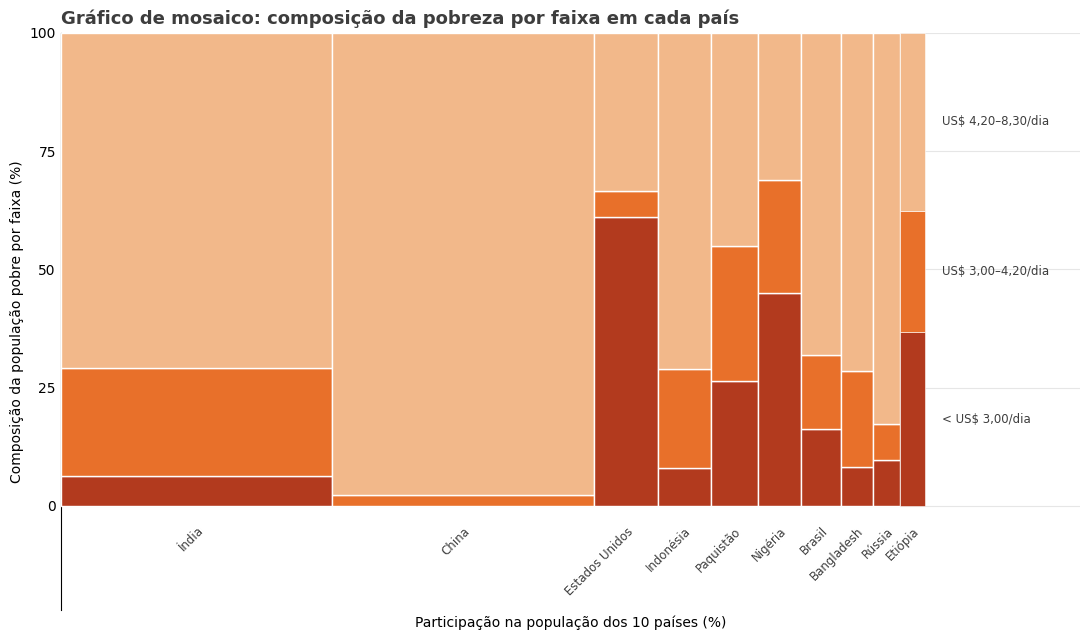

In [7]:
mosaico = pd.read_csv("../Data/marimekko_pobreza_top10_3linhas.csv", sep="\t", encoding="utf-16")
mosaico = mosaico.rename(columns={
    "país": "País",
    "população total": "População_total",
    "população abaixo de US$ 3,00 por dia": "Pop_300",
    "população abaixo de US$ 4,20 por dia": "Pop_420",
    "população abaixo de US$ 8,30 por dia": "Pop_830",
})
mosaico = mosaico.sort_values("População_total", ascending=False).reset_index(drop=True)

# largura = participação de cada país no total da população dos 10 países (soma 100%)
larguras_m = mosaico["População_total"].to_numpy() / mosaico["População_total"].sum() * 100
bordas_m = np.concatenate([[0], np.cumsum(larguras_m)])

# altura = três faixas de pobreza (mutuamente exclusivas), como % da população pobre
# do próprio país (Pop_830, a faixa mais ampla) — soma 100% em cada barra
faixa_extrema = mosaico["Pop_300"].to_numpy()
faixa_moderada = (mosaico["Pop_420"] - mosaico["Pop_300"]).to_numpy()
faixa_leve = (mosaico["Pop_830"] - mosaico["Pop_420"]).to_numpy()
total_pobre = mosaico["Pop_830"].to_numpy()

pct_extrema = faixa_extrema / total_pobre * 100
pct_moderada = faixa_moderada / total_pobre * 100
pct_leve = faixa_leve / total_pobre * 100

CORES_FAIXA = {"< US$ 3,00/dia": "#B23A1E", "US$ 3,00–4,20/dia": "#E8702A", "US$ 4,20–8,30/dia": "#F2B88A"}

fig, ax = plt.subplots(figsize=(11, 6.5))

for esquerda, largura, e, m, l in zip(bordas_m[:-1], larguras_m, pct_extrema, pct_moderada, pct_leve):
    contorno = 0.4 if largura < 3 else 1.0
    ax.bar(esquerda, e, width=largura, align="edge", color=CORES_FAIXA["< US$ 3,00/dia"],
           edgecolor="white", linewidth=contorno, zorder=3)
    ax.bar(esquerda, m, bottom=e, width=largura, align="edge", color=CORES_FAIXA["US$ 3,00–4,20/dia"],
           edgecolor="white", linewidth=contorno, zorder=3)
    ax.bar(esquerda, l, bottom=e + m, width=largura, align="edge", color=CORES_FAIXA["US$ 4,20–8,30/dia"],
           edgecolor="white", linewidth=contorno, zorder=3)

for esquerda, largura, pais in zip(bordas_m[:-1], larguras_m, mosaico["País"]):
    centro = esquerda + largura / 2
    ax.text(centro, -4, pais, ha="right", va="top", fontsize=8.5, color=GRAFITE,
            rotation=45, rotation_mode="anchor")

# Legenda como rótulo alinhado com as faixas do país mais à direita, em vez de caixa de legenda
ultimo_e, ultimo_m, ultimo_l = pct_extrema[-1], pct_moderada[-1], pct_leve[-1]
posicoes_legenda = [ultimo_e / 2, ultimo_e + ultimo_m / 2, ultimo_e + ultimo_m + ultimo_l / 2]
for y, texto in zip(posicoes_legenda, CORES_FAIXA.keys()):
    ax.text(102, y, texto, ha="left", va="center", fontsize=8.5, color=GRAFITE)

ax.set_xlim(0, 118)
ax.set_ylim(-22, 100)
ax.set_xlabel("Participação na população dos 10 países (%)")
ax.set_ylabel("Composição da população pobre por faixa (%)")
ax.set_title("Gráfico de mosaico: composição da pobreza por faixa em cada país",
             loc="left", fontsize=13, color=GRAFITE, weight="bold")

ax.set_yticks([0, 25, 50, 75, 100])
ax.yaxis.grid(True, color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xticks([])
for lado in ("top", "right", "bottom"):
    ax.spines[lado].set_visible(False)
ax.tick_params(length=0)

fig.tight_layout()
plt.show()

Um gráfico de mosaico também pode servir como uma extensão de um gráfico de barras empilhadas. Esses gráficos mostram os ganhos decorrentes da Lei de Cortes de Impostos e Empregos de 2017 (*Tax Cuts and Jobs Act of 2017*) para unidades fiscais situadas em diferentes pontos da distribuição de renda dos Estados Unidos. O gráfico de barras empilhadas à esquerda apresenta cinco categorias de ganhos fiscais distribuídas por onze faixas de renda, sendo que todas as barras possuem a mesma largura. Se ajustarmos a largura das barras proporcionalmente ao número de unidades fiscais em cada faixa de renda — de modo que a altura vertical total do gráfico corresponda a 100% —, podemos criar o gráfico de mosaico exibido à direita. Note que o gráfico de mosaico oferece uma noção mais clara da distribuição do número de contribuintes nos diferentes grupos; no entanto, como há relativamente poucas pessoas na faixa de renda mais alta, torna-se mais difícil visualizar esses valores.

Os dois gráficos a seguir usam os mesmos dados de tempo de execução (`tempos_execucao_paralela.csv`), decompostos em computação, comunicação, sincronização e entrada/saída para diferentes números de processos. O primeiro é um gráfico de barras (horizontais) empilhadas normalizado a 100%, destacando a computação em laranja. O segundo é um gráfico de mosaico: a largura de cada barra é proporcional ao tempo total de execução em relação ao tempo com um único processo, enquanto a altura mantém a mesma composição percentual entre as etapas.

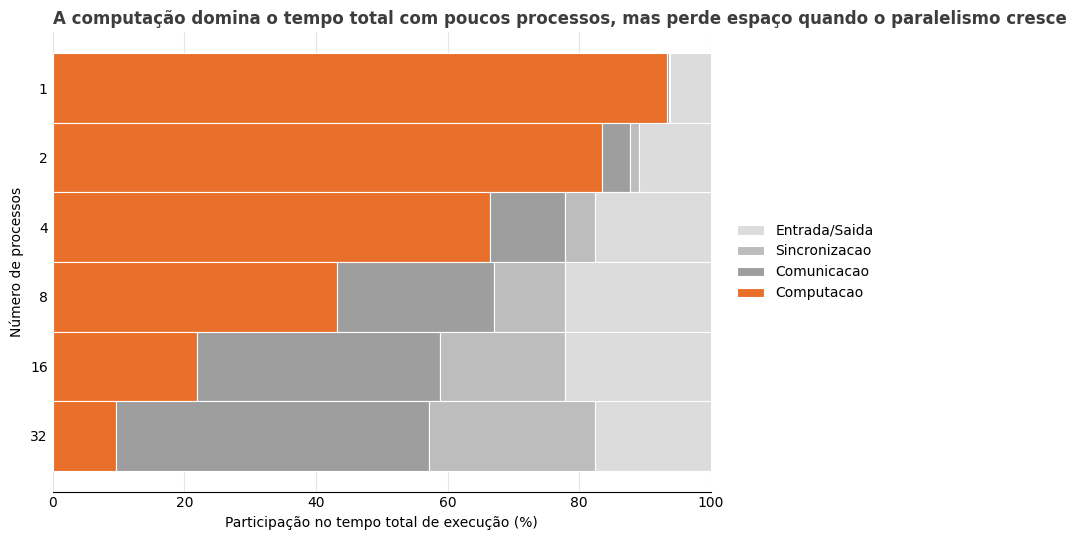

In [8]:
tempos = pd.read_csv("../Data/tempos_execucao_paralela.csv")
ordem_etapas = ["Computacao", "Comunicacao", "Sincronizacao", "Entrada_Saida"]
tabela = tempos.pivot_table(index="n_processos", columns="etapa", values="tempo_s")[ordem_etapas]

GRAFITE = "#3D3D3D"
LARANJA = "#E8702A"
CORES_ETAPA = {"Computacao": LARANJA, "Comunicacao": "#9E9E9E",
               "Sincronizacao": "#BDBDBD", "Entrada_Saida": "#DCDCDC"}

fracoes = tabela.div(tabela.sum(axis=1), axis=0) * 100
categorias = [str(n) for n in tabela.index]
pos = np.arange(len(categorias))

fig, ax = plt.subplots(figsize=(9, 5.5))
base = np.zeros(len(categorias))
for etapa in ordem_etapas:
    ax.barh(pos, fracoes[etapa], left=base, height=1.0, label=etapa.replace("_", "/"),
            color=CORES_ETAPA[etapa], edgecolor="white", linewidth=0.8, zorder=3)
    base += fracoes[etapa].to_numpy()

ax.set_yticks(pos, categorias)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Participação no tempo total de execução (%)")
ax.set_ylabel("Número de processos")
ax.set_title("A computação domina o tempo total com poucos processos, mas perde espaço"
             " quando o paralelismo cresce", loc="left", fontsize=12, color=GRAFITE, weight="bold")

ax.xaxis.grid(True, color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.tick_params(length=0)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))

fig.tight_layout()
plt.show()

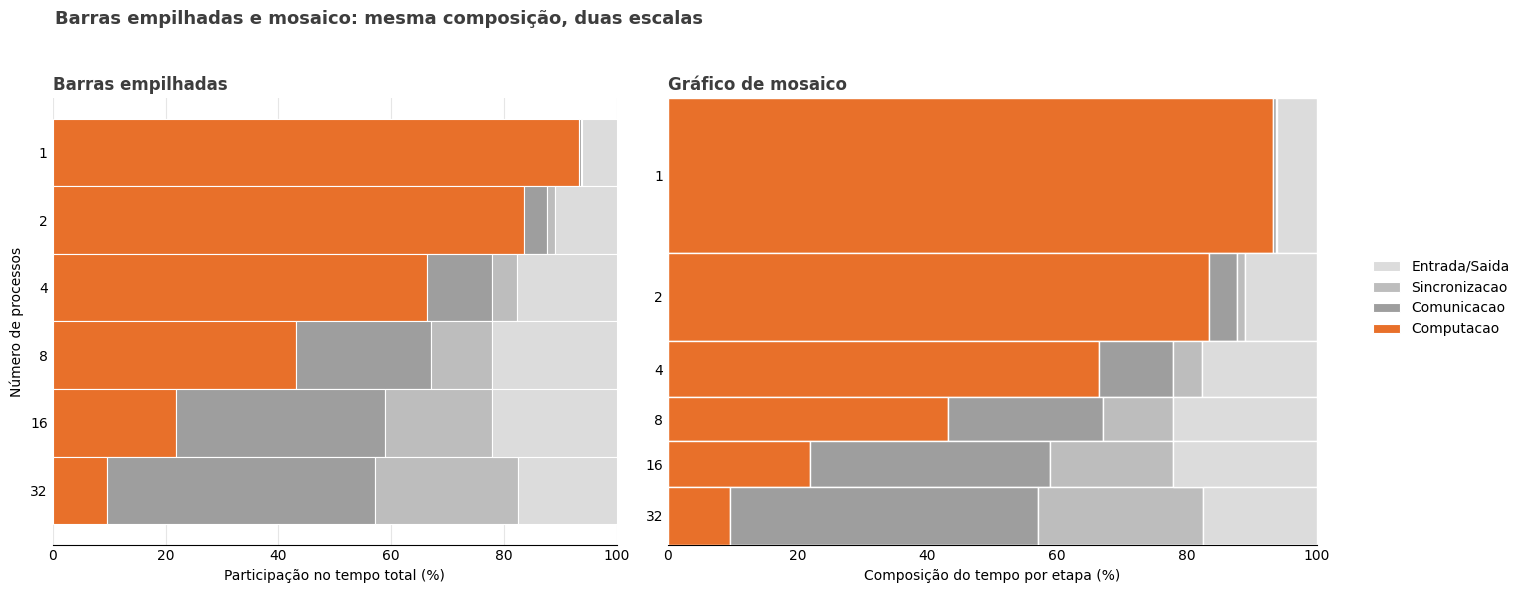

In [10]:
# Comparação lado a lado: barras empilhadas e gráfico de mosaico
categorias_np = [str(n) for n in tabela.index]
pos_np = np.arange(len(categorias_np))
total_tempo = tabela.sum(axis=1)
alturas_np = (total_tempo / total_tempo.loc[1] * 100).to_numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 1.15]})

# Gráfico de barras empilhadas da célula 8
base = np.zeros(len(categorias_np))
for etapa in ordem_etapas:
    ax1.barh(pos_np, fracoes[etapa], left=base, height=1.0,
             color=CORES_ETAPA[etapa], edgecolor="white", linewidth=0.8,
             label=etapa.replace("_", "/"), zorder=3)
    base += fracoes[etapa].to_numpy()

ax1.set_yticks(pos_np, categorias_np)
ax1.invert_yaxis()
ax1.set_xlim(0, 100)
ax1.set_xlabel("Participação no tempo total (%)")
ax1.set_ylabel("Número de processos")
ax1.set_title("Barras empilhadas", loc="left", fontsize=12, color=GRAFITE, weight="bold")
ax1.xaxis.grid(True, color="#E6E6E6", linewidth=0.8)

# Gráfico de mosaico: composição na largura e tempo total na altura
limites_y = np.concatenate([[0], np.cumsum(alturas_np)])
centros_y = (limites_y[:-1] + limites_y[1:]) / 2
base_mosaico = np.zeros(len(categorias_np))
for etapa in ordem_etapas:
    ax2.barh(centros_y, fracoes[etapa], left=base_mosaico, height=alturas_np,
             color=CORES_ETAPA[etapa], edgecolor="white", linewidth=1.0,
             label=etapa.replace("_", "/"), zorder=3)
    base_mosaico += fracoes[etapa].to_numpy()

ax2.set_xlim(0, 100)
ax2.set_ylim(0, limites_y[-1])
ax2.set_yticks(centros_y, categorias_np)
ax2.invert_yaxis()
ax2.set_xlabel("Composição do tempo por etapa (%)")
ax2.set_title("Gráfico de mosaico", loc="left", fontsize=12, color=GRAFITE, weight="bold")
ax2.xaxis.grid(True, color="#E6E6E6", linewidth=0.8)

for ax in (ax1, ax2):
    ax.set_axisbelow(True)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.tick_params(length=0)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles[::-1], labels[::-1], frameon=False, loc="center left", bbox_to_anchor=(0.91, 0.5))
fig.suptitle("Barras empilhadas e mosaico: mesma composição, duas escalas", x=0.04,
             ha="left", fontsize=13, color=GRAFITE, weight="bold")
fig.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()